# **Phase 1 — Data Cleaning & Quality Check**

In [1]:
import os
import inspect
import time
import traceback
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from datetime import date
import missingno as ms
import sweetviz as sv

In [2]:
ROOT_DIR = Path().cwd().parents[0]
os.chdir(ROOT_DIR)

from src.config import Data, Db_connection
os.chdir(ROOT_DIR/Data)
from load_tables import read_tables, DATA_DIR
os.chdir(ROOT_DIR/Db_connection)
from db_connection import engine

C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\-NexaTel-Customer-Churn-Analytics-Project
data dir C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\-NexaTel-Customer-Churn-Analytics-Project\data\raw


2026-09-18 10:38:19,007 - INFO - getting env variables...
2026-09-18 10:38:19,008 - INFO - Creadentials initiated Successfuly
2026-09-18 10:38:19,009 - INFO - DB URL Creating...
2026-09-18 10:38:19,010 - INFO - DB URL Initiated.
2026-09-18 10:38:19,010 - INFO - creating DB Engine...
2026-09-18 10:38:19,209 - INFO - engine created successfuly.


In [3]:
pd.set_option("display.float_format", "{:.2f}".format)
np.set_printoptions(precision = 2, suppress = True)

In [4]:
inspect.signature(read_tables)

<Signature (table_name: str, dir_path: pathlib._local.WindowsPath) -> pandas.core.frame.DataFrame>

In [5]:
inspect.getdoc(read_tables)

In [6]:
customers_data = read_tables("customers", DATA_DIR)

2026-09-18 10:38:19,947 - INFO - changing directory to raw...
2026-09-18 10:38:19,951 - INFO - reading dataset...
2026-09-18 10:38:20,156 - INFO - dataset customers.csv readed successfuly


['billing.csv', 'cities.csv', 'complaints.csv', 'contracts.csv', 'customers.csv', 'customer_feedback.csv', 'data_quality_issue_log.csv', 'devices.csv', 'employees.csv', 'marketing_campaigns.csv', 'network_quality.csv', 'payments.csv', 'plans.csv', 'plan_history.csv', 'recharges.csv', 'regions.csv', 'retention_campaigns.csv', 'states.csv', 'stores.csv', 'subscriptions.csv', 'support_tickets.csv', 'usage_data.csv', 'usage_sms.csv', 'usage_voice.csv']
Filename: C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\-NexaTel-Customer-Churn-Analytics-Project\src\data\load_tables.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    20    222.5 MiB    222.5 MiB           1   @profile
    21                                         def read_tables(table_name: str, dir_path: pathlib._local.WindowsPath)-> pd.DataFrame:
    22    222.5 MiB      0.0 MiB           1       try:
    23    222.5 MiB      0.0 MiB           1           logging.info("changing directory to raw...")
    24  

In [7]:
try:
    display(customers_data.head(3))
except ValueError:
    print("incurrect precision value in pd.set_option()")
    print(traceback.print_exc())

,customer_id,first_name,last_name,gender,date_of_birth,age,email,phone_number,address,city_id,...,occupation,annual_income_inr,customer_segment,product_line,plan_id,acquisition_channel,acquisition_date,tenure_months,customer_status,churn_date
0,C0000001,Harish,Shetty,Male,31-03-1988,38,harish.shetty909@yahoo.in,916647481156,"Plot 382, Tilak Lane, Raipur",CT0026,...,School Teacher,791058.00,Mass,Prepaid Mobile,PL002,Retail Store,15-01-2026,2,Churned,22-03-2026
1,C0000002,Anjali,Khan,Female,31-03-1974,52,anjali.khan525@rediffmail.com,918116536619,"Door No. 269, Civil Lines Colony, Gurugram",CT0009,...,Small Business Owner,1385499.00,Premium,Fiber Broadband,PL017,Retail Store,01-01-2014,146,Active,NaN
2,C0000003,Arjun,Hegde,Male,31-03-1978,48,arjun.hegde378@hotmail.com,918958153134,"House No. 320, Garden Nagar, Vadodara",CT0020,...,Auto/Cab Driver,394773.00,Enterprise,Enterprise,PL021,Tele-sales,11-11-2015,1,Churned,22-12-2015


In [8]:
customers_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19076 entries, 0 to 19075
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          19076 non-null  object 
 1   first_name           19076 non-null  object 
 2   last_name            19076 non-null  object 
 3   gender               19076 non-null  object 
 4   date_of_birth        19076 non-null  object 
 5   age                  19076 non-null  int64  
 6   email                18331 non-null  object 
 7   phone_number         19076 non-null  int64  
 8   address              18696 non-null  object 
 9   city_id              19076 non-null  object 
 10  city_name            19076 non-null  object 
 11  state_id             19076 non-null  object 
 12  pin_code             19076 non-null  int64  
 13  city_tier            19076 non-null  object 
 14  region_id            19076 non-null  object 
 15  occupation           19076 non-null 

In [9]:
print("Totl Duplicte Customer_id's : ",len(customers_data[customers_data.duplicated()]))
print("", end = "\n")
customers_data[customers_data.duplicated()]

Totl Duplicte Customer_id's :  76



,customer_id,first_name,last_name,gender,date_of_birth,age,email,phone_number,address,city_id,...,occupation,annual_income_inr,customer_segment,product_line,plan_id,acquisition_channel,acquisition_date,tenure_months,customer_status,churn_date
19000,C0002573,Sana,Mahanta,Female,31-03-1989,37,sana.mahanta578@rediffmail.com,919749518285,"Plot 198, Lakshmi Street, Kolkata",CT0005,...,Retail Shopkeeper,867362.00,Premium,Fiber Broadband,PL018,Online,25-03-2019,84,Active,NaN
19001,C0013052,Sanjay,Rao,Male,31-03-2008,18,sanjay.rao738@outlook.com,919375664569,"Apartment 18, Shivaji Street, Patna",CT0021,...,Nurse,280646.00,Premium,Postpaid Mobile,PL011,Online,01-01-2014,146,Active,NaN
19002,C0008793,Aadhya,Mishra,Female,31-03-1998,28,aadhya.mishra467@yahoo.in,917037057659,"Shop No. 305, Shivaji Layout, Shimla",CT0061,...,Police Officer,528283.00,Value,Prepaid Mobile,PL004,Referral,04-05-2016,118,Active,NaN
19003,C0008376,Krishna,Borah,Male,31-03-1974,52,krishna.borah344@gmail.com,917943543437,"Door No. 77, Model Town Nagar, Raipur",CT0026,...,Lawyer,1486031.00,Premium,Postpaid Mobile,PL011,Online,01-01-2014,146,Active,NaN
19004,C0008537,Meera,Pawar,Female,31-03-1994,32,meera.pawar119@gmail.com,919661476939,"Shop No. 119, Indira Lane, Pune",CT0007,...,Freelancer,1403054.00,Premium,Postpaid Mobile,PL009,Online,25-10-2025,5,Active,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19071,C0008103,Ishaan,Rao,Male,31-03-1997,29,ishaan.rao851@yahoo.in,917081721176,"Door No. 1, New Nagar, Nashik",CT0030,...,Retail Shopkeeper,NaN,Premium,5G,PL013,Retail Store,02-11-2021,52,Active,NaN
19072,C0016657,Aryan,Chopra,Male,31-03-1996,30,aryan.chopra495@yahoo.in,918139362445,"Plot 326, Patel Phase, Indore",CT0013,...,Auto/Cab Driver,255361.00,Premium,Postpaid Mobile,PL010,Partner/Reseller,28-06-2014,141,Active,NaN
19073,C0015135,Rajesh,Pillai,Male,31-03-1980,46,rajesh.pillai829@yahoo.in,918496243799,"Door No. 9, Shivaji Layout, Bikaner",CT0051,...,Freelancer,835314.00,Value,Prepaid Mobile,PL004,Online,06-11-2024,10,Churned,02-10-2025
19074,C0000169,Yash,Shinde,Male,01-04-1971,55,yash.shinde18@outlook.com,918905657883,"Flat 66, Lake Nagar, Belagavi",CT0041,...,Sales Executive,506678.00,Value,Prepaid Mobile,PL003,Retail Store,08-11-2020,64,Active,NaN


In [10]:
customers_data.drop_duplicates(inplace = True)

In [11]:
customers_data.isnull().sum()

customer_id                0
first_name                 0
last_name                  0
gender                     0
date_of_birth              0
age                        0
email                    744
phone_number               0
address                  380
city_id                    0
city_name                  0
state_id                   0
pin_code                   0
city_tier                  0
region_id                  0
occupation                 0
annual_income_inr        950
customer_segment           0
product_line               0
plan_id                    0
acquisition_channel        0
acquisition_date           0
tenure_months              0
customer_status            0
churn_date             15494
dtype: int64

In [12]:
len(customers_data) / customers_data.isnull().sum()

customer_id             inf
first_name              inf
last_name               inf
gender                  inf
date_of_birth           inf
age                     inf
email                 25.54
phone_number            inf
address               50.00
city_id                 inf
city_name               inf
state_id                inf
pin_code                inf
city_tier               inf
region_id               inf
occupation              inf
annual_income_inr     20.00
customer_segment        inf
product_line            inf
plan_id                 inf
acquisition_channel     inf
acquisition_date        inf
tenure_months           inf
customer_status         inf
churn_date             1.23
dtype: float64

In [13]:
customers_data["phone_number"].sample(n = 15)

16775    918664401325
14016    918607199457
4747     917802348685
16519    919403092908
12550    917701181396
12334    917176296759
17081    917271062184
12189    918816220866
10702    917582680834
3129     917714788520
5980     919630265194
10988    916572960146
10317    916156568566
12909    918719831870
4056     919186783537
Name: phone_number, dtype: int64

In [14]:
customers_data[customers_data["age"] > 100]

,customer_id,first_name,last_name,gender,date_of_birth,age,email,phone_number,address,city_id,...,occupation,annual_income_inr,customer_segment,product_line,plan_id,acquisition_channel,acquisition_date,tenure_months,customer_status,churn_date
751,C0000752,Anika,Pandey,Female,31-03-1989,220,anika.pandey265@rediffmail.com,916763149388,"Villa 136, Vivekananda Phase, Chennai",CT0004,...,Farmer,129668.00,Mass,Prepaid Mobile,PL001,Retail Store,14-05-2023,34,Active,NaN
834,C0000835,Sridevi,Sen,Female,31-03-1988,220,sridevi.sen783@gmail.com,916550906093,"Door No. 72, New Phase, Tirupati",CT0042,...,Retired,238954.00,Value,Prepaid Mobile,PL004,Referral,26-07-2018,92,Active,NaN
2917,C0002918,Geeta,Qureshi,Female,31-03-1984,130,geeta.qureshi848@rediffmail.com,917236699438,"House No. 328, Vivekananda Street, Kollam",CT0046,...,Bank Officer,NaN,Value,Prepaid Mobile,PL005,Online,01-01-2014,146,Active,NaN
3026,C0003027,Aarav,Shaikh,Male,01-04-1971,220,aarav.shaikh942@hotmail.com,916255560170,"House No. 66, Janpath Phase, Amritsar",CT0032,...,Bank Officer,1049990.00,Enterprise,IoT Solutions,PL024,Online,14-09-2023,30,Active,NaN
3822,C0003823,Zara,Trivedi,Female,01-04-1983,220,zara.trivedi587@yahoo.in,15145,"Villa 12, Park View Colony, Gwalior",CT0048,...,HR Executive,376701.00,Value,Fiber Broadband,PL015,Retail Store,01-01-2014,146,Active,NaN
3824,C0003825,Saanvi,Aggarwal,Female,01-04-1979,220,saanvi.aggarwal636@outlook.com,919008185404,"Door No. 252, Vasant Marg, Mumbai",CT0002,...,Marketing Manager,2047567.00,Premium,Postpaid Mobile,PL009,Referral,26-03-2022,48,Active,NaN
4639,C0004640,Tarun,Khanna,Male,31-03-1982,130,tarun.khanna43@hotmail.com,916853291796,"Apartment 241, Park View Cross, Belagavi",CT0041,...,Chartered Accountant,2818203.00,Mass,Prepaid Mobile,PL001,Partner/Reseller,08-08-2023,31,Active,NaN
5159,C0005160,Kavitha,Nayak,Female,31-03-1969,130,kavitha.nayak409@rediffmail.com,919528137142,"Flat 371, Vasant Road, Shillong",CT0065,...,Doctor,1948773.00,Premium,5G,PL012,Tele-sales,10-04-2020,71,Active,NaN
5290,C0005291,Kiara,More,Female,31-03-2006,130,kiara.more1@gmail.com,916338889455,"Villa 347, Garden Sector, Nashik",CT0030,...,Operations Manager,NaN,Premium,Prepaid Mobile,PL006,Retail Store,01-01-2014,146,Active,NaN
8934,C0008935,Imran,Chandran,Male,31-03-2004,130,imran.chandran734@gmail.com,918078728994,"Plot 388, Patel Street, Bikaner",CT0051,...,Retail Shopkeeper,398116.00,Mass,Prepaid Mobile,PL002,Partner/Reseller,25-01-2025,14,Active,NaN


In [15]:
invalid_numbers = []
for i in customers_data["phone_number"].values:
    phone_number = str(i)
    if len(phone_number) < 12:
        invalid_numbers.append(phone_number)

print("total invalide Phone Numbers : ", len(invalid_numbers))
print("", end = "\n")
display(invalid_numbers)

total invalide Phone Numbers :  228



['57059',
 '13624',
 '91566',
 '75835',
 '55071',
 '70233',
 '84892',
 '24255',
 '97577',
 '47167',
 '48071',
 '35223',
 '2856',
 '28478',
 '83020',
 '45452',
 '68197',
 '70115',
 '24011',
 '22307',
 '44055',
 '30967',
 '6457',
 '54545',
 '27453',
 '53745',
 '90947',
 '10913',
 '18714',
 '58756',
 '69041',
 '29892',
 '41516',
 '68721',
 '43753',
 '58946',
 '46285',
 '76499',
 '16080',
 '75289',
 '18314',
 '65815',
 '52936',
 '82878',
 '85010',
 '60717',
 '51533',
 '99101',
 '35933',
 '6833',
 '96452',
 '35497',
 '75729',
 '84085',
 '88894',
 '24333',
 '15145',
 '50165',
 '43852',
 '11429',
 '65630',
 '90455',
 '97841',
 '99161',
 '87552',
 '78282',
 '13664',
 '6377',
 '25260',
 '71040',
 '62346',
 '31776',
 '32624',
 '93006',
 '29679',
 '16557',
 '86398',
 '9716',
 '83248',
 '58038',
 '84406',
 '94991',
 '32721',
 '73589',
 '35946',
 '87144',
 '16249',
 '20017',
 '12061',
 '23841',
 '56678',
 '59760',
 '16253',
 '75834',
 '52567',
 '36194',
 '38957',
 '7074',
 '19403',
 '49071',
 '7262

In [16]:
customers_data[customers_data["phone_number"].duplicated()]

,customer_id,first_name,last_name,gender,date_of_birth,age,email,phone_number,address,city_id,...,occupation,annual_income_inr,customer_segment,product_line,plan_id,acquisition_channel,acquisition_date,tenure_months,customer_status,churn_date
7198,C0007199,Srinivas,Gaikwad,Male,31-03-1997,29,srinivas.gaikwad697@hotmail.com,45452,"Door No. 306, Gandhi Phase, Nashik",CT0030,...,Homemaker,35901.00,Value,Postpaid Mobile,PL007,Online,10-03-2021,60,Active,NaN


In [17]:
customers_data["email"].sample(n = 20)

13051            sanjay.rao738@outlook.com
10298             sunil.reddy492@gmail.com
1274          krishna.gowda933@outlook.com
8582             mahesh.tiwari191@yahoo.in
9354         akash.chakraborty295@yahoo.in
12948              rajesh.more606@yahoo.in
16167     sneha.chakraborty666@hotmail.com
8262           aarav.pathan389@hotmail.com
14633          yash.krishnan61@hotmail.com
9956          nandini.menon273@outlook.com
3794           preeti.ghosh576@hotmail.com
3028           ramesh.yadav497@outlook.com
10836           myra.sharma958@hotmail.com
11651             sanjay.ahmed910@yahoo.in
18658        divya.mehrotra837@hotmail.com
16833        gopal.tiwari11@rediffmail.com
2376     krishna.kammela554@rediffmail.com
3902          tanvi.nair658@rediffmail.com
17337         pari.joshi583@rediffmail.com
12878        zaid.sheikh542@rediffmail.com
Name: email, dtype: object

In [18]:
len(customers_data[customers_data["email"].duplicated()])

785

In [19]:
customers_data["date_of_birth"] = pd.to_datetime(customers_data["date_of_birth"]).dt.date

C:\Users\KISHORE\AppData\Local\Temp\ipykernel_1612\2624513091.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  customers_data["date_of_birth"] = pd.to_datetime(customers_data["date_of_birth"]).dt.date


In [20]:
customers_data["date_of_birth"]

0        1988-03-31
1        1974-03-31
2        1978-03-31
3        1988-03-31
4        1988-03-31
            ...    
18995    1989-03-31
18996    1969-03-31
18997    1973-03-31
18998    1999-04-01
18999    1999-04-01
Name: date_of_birth, Length: 19000, dtype: object

In [21]:
invalid_codes = []
for i in customers_data["pin_code"].values:
    pin_code = str(i)
    if len(pin_code) < 6:
        invalid_codes.append(pin_code)

print("total invalide Pin Codes : ", len(invalid_codes))
print("", end = "\n")
display(invalid_codes)

total invalide Pin Codes :  190



['9172',
 '7123',
 '7128',
 '4841',
 '8109',
 '2180',
 '1470',
 '5514',
 '9869',
 '6401',
 '1207',
 '3798',
 '5845',
 '6178',
 '7063',
 '4757',
 '9851',
 '1553',
 '3230',
 '2387',
 '3653',
 '1360',
 '9885',
 '4436',
 '540',
 '8403',
 '5533',
 '7538',
 '2852',
 '6791',
 '8807',
 '7492',
 '5707',
 '744',
 '6680',
 '3782',
 '8465',
 '1035',
 '1381',
 '2511',
 '9555',
 '4543',
 '3650',
 '6715',
 '1386',
 '8213',
 '5385',
 '8031',
 '7299',
 '4284',
 '6621',
 '9034',
 '8982',
 '3221',
 '8691',
 '9706',
 '8766',
 '2307',
 '1203',
 '4496',
 '3265',
 '9402',
 '6991',
 '7555',
 '5160',
 '7085',
 '5257',
 '8788',
 '9753',
 '368',
 '1929',
 '9534',
 '9058',
 '355',
 '5285',
 '9456',
 '2127',
 '1132',
 '8840',
 '7704',
 '879',
 '1780',
 '2091',
 '6045',
 '9411',
 '4216',
 '828',
 '6683',
 '7152',
 '1677',
 '2406',
 '2089',
 '124',
 '9399',
 '5276',
 '1749',
 '8600',
 '4642',
 '396',
 '7353',
 '3341',
 '4184',
 '7816',
 '1877',
 '2993',
 '8429',
 '3468',
 '1968',
 '5033',
 '9831',
 '4113',
 '1581',


In [22]:
customers_data.describe()

,age,phone_number,pin_code,annual_income_inr,tenure_months
count,19000.00,19000.00,19000.00,18050.00,19000.00
mean,36.07,906960836379.91,472584.42,871696.30,76.93
std,12.13,99963338550.24,216542.72,675974.84,48.17
min,-5.00,181.00,124.00,122.00,0.00
25%,27.00,916931381773.25,305495.75,383177.00,34.00
50%,36.00,917945560022.00,474146.00,692762.00,76.00
75%,44.00,918964664574.25,641646.50,1192239.75,122.00
max,220.00,919999853202.00,834999.00,3999507.00,146.00


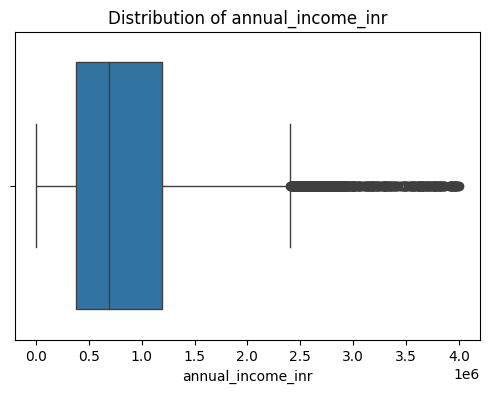

In [23]:
plt.figure(figsize = (6,4))
sns.boxplot(x = customers_data["annual_income_inr"])
plt.title("Distribution of annual_income_inr")
plt.show()

In [24]:
Q1 = customers_data["annual_income_inr"].quantile(0.25)
Q3 = customers_data["annual_income_inr"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 - 1.5 * IQR

print("Low valued Outliers: ")
print("", end = "\n")
print("Total", len(customers_data[customers_data["annual_income_inr"] < lower_bound]))
print("", end = "\n")
display(customers_data[customers_data["annual_income_inr"] < lower_bound])

print("High valued Outliers: ")
print("", end = "\n")
print("Total", len(customers_data[customers_data["annual_income_inr"] > upper_bound]))
print("", end = "\n")
display(customers_data[customers_data["annual_income_inr"] > upper_bound])

Low valued Outliers: 

Total 0



,customer_id,first_name,last_name,gender,date_of_birth,age,email,phone_number,address,city_id,...,occupation,annual_income_inr,customer_segment,product_line,plan_id,acquisition_channel,acquisition_date,tenure_months,customer_status,churn_date


High valued Outliers: 

Total 18050



,customer_id,first_name,last_name,gender,date_of_birth,age,email,phone_number,address,city_id,...,occupation,annual_income_inr,customer_segment,product_line,plan_id,acquisition_channel,acquisition_date,tenure_months,customer_status,churn_date
0,C0000001,Harish,Shetty,Male,1988-03-31,38,harish.shetty909@yahoo.in,916647481156,"Plot 382, Tilak Lane, Raipur",CT0026,...,School Teacher,791058.00,Mass,Prepaid Mobile,PL002,Retail Store,15-01-2026,2,Churned,22-03-2026
1,C0000002,Anjali,Khan,Female,1974-03-31,52,anjali.khan525@rediffmail.com,918116536619,"Door No. 269, Civil Lines Colony, Gurugram",CT0009,...,Small Business Owner,1385499.00,Premium,Fiber Broadband,PL017,Retail Store,01-01-2014,146,Active,NaN
2,C0000003,Arjun,Hegde,Male,1978-03-31,48,arjun.hegde378@hotmail.com,918958153134,"House No. 320, Garden Nagar, Vadodara",CT0020,...,Auto/Cab Driver,394773.00,Enterprise,Enterprise,PL021,Tele-sales,11-11-2015,1,Churned,22-12-2015
3,C0000004,Vidya,Parmar,Female,1988-03-31,38,vidya.parmar387@hotmail.com,917763920098,"House No. 204, Industrial Street, Nagpur",CT0015,...,Operations Manager,1977532.00,Premium,Prepaid Mobile,PL006,Tele-sales,2014/10/18,137,Active,NaN
4,C0000005,Arjun,Saxena,Male,1988-03-31,38,arjun.saxena410@yahoo.in,916787478273,"Flat 156, Krishna Sector, Warangal",CT0043,...,Retired,847300.00,Value,Prepaid Mobile,PL003,Online,20-10-2014,108,Churned,22-10-2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18994,C0018995,Myra,Ansari,Female,1984-03-31,42,myra.ansari273@rediffmail.com,918046271465,"Plot 164, Old Marg, Chandigarh",CT0023,...,Retired,699112.00,Premium,Postpaid Mobile,PL011,Partner/Reseller,2023/05/30,34,Active,NaN
18995,C0018996,Mohit,Verma,Male,1989-03-31,37,user402_at_mail,918282937457,"Villa 174, MG Nagar, Thiruvananthapuram",CT0034,...,Delivery Partner,213993.00,Premium,Smart Home,PL025,Partner/Reseller,10-03-2023,36,Active,NaN
18997,C0018998,Aryan,Yadav,Male,1973-03-31,53,aryan.yadav480@outlook.com,918557275501,"Villa 273, Vivekananda Marg, Mysuru",CT0027,...,HR Executive,515247.00,Premium,Postpaid Mobile,PL010,Online,08-11-2023,28,Active,NaN
18998,C0018999,Abhishek,Saxena,Male,1999-04-01,27,abhishek.saxena498@hotmail.com,919128573669,"Shop No. 119, Old Lane, Durgapur",CT0053,...,Nurse,325175.00,Value,Prepaid Mobile,PL004,Referral,30-06-2015,129,Active,NaN


In [25]:
subscriptions_data = read_tables("subscriptions", DATA_DIR)
billing_data = read_tables("billing", DATA_DIR)
usage_data = read_tables("usage_data", DATA_DIR)
usage_sms_data = read_tables("usage_sms", DATA_DIR)
usage_voice_data = read_tables("usage_voice", DATA_DIR)

2026-09-18 10:38:21,200 - INFO - changing directory to raw...
2026-09-18 10:38:21,204 - INFO - reading dataset...
2026-09-18 10:38:21,279 - INFO - dataset subscriptions.csv readed successfuly
2026-09-18 10:38:21,285 - INFO - changing directory to raw...
2026-09-18 10:38:21,290 - INFO - reading dataset...


['billing.csv', 'cities.csv', 'complaints.csv', 'contracts.csv', 'customers.csv', 'customer_feedback.csv', 'data_quality_issue_log.csv', 'devices.csv', 'employees.csv', 'marketing_campaigns.csv', 'network_quality.csv', 'payments.csv', 'plans.csv', 'plan_history.csv', 'recharges.csv', 'regions.csv', 'retention_campaigns.csv', 'states.csv', 'stores.csv', 'subscriptions.csv', 'support_tickets.csv', 'usage_data.csv', 'usage_sms.csv', 'usage_voice.csv']
Filename: C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\-NexaTel-Customer-Churn-Analytics-Project\src\data\load_tables.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    20    238.4 MiB    238.4 MiB           1   @profile
    21                                         def read_tables(table_name: str, dir_path: pathlib._local.WindowsPath)-> pd.DataFrame:
    22    238.4 MiB      0.0 MiB           1       try:
    23    238.4 MiB      0.0 MiB           1           logging.info("changing directory to raw...")
    24  

2026-09-18 10:38:21,595 - INFO - dataset billing.csv readed successfuly
2026-09-18 10:38:21,599 - INFO - changing directory to raw...
2026-09-18 10:38:21,602 - INFO - reading dataset...
2026-09-18 10:38:21,676 - INFO - dataset usage_data.csv readed successfuly
2026-09-18 10:38:21,680 - INFO - changing directory to raw...
2026-09-18 10:38:21,683 - INFO - reading dataset...
2026-09-18 10:38:21,796 - INFO - dataset usage_sms.csv readed successfuly


Filename: C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\-NexaTel-Customer-Churn-Analytics-Project\src\data\load_tables.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    20    246.0 MiB    246.0 MiB           1   @profile
    21                                         def read_tables(table_name: str, dir_path: pathlib._local.WindowsPath)-> pd.DataFrame:
    22    246.0 MiB      0.0 MiB           1       try:
    23    246.0 MiB      0.0 MiB           1           logging.info("changing directory to raw...")
    24    246.0 MiB      0.0 MiB           1           files_list = os.listdir(dir_path)
    25    246.0 MiB      0.0 MiB           1           os.chdir(dir_path)
    26    246.0 MiB      0.0 MiB           1           print(files_list)
    27    246.0 MiB      0.0 MiB           1           logging.info("reading dataset...")
    28    246.0 MiB      0.0 MiB           1           for file in files_list:
    29    246.0 MiB      0.0 MiB           1            

2026-09-18 10:38:21,801 - INFO - changing directory to raw...
2026-09-18 10:38:21,804 - INFO - reading dataset...
2026-09-18 10:38:21,891 - INFO - dataset usage_voice.csv readed successfuly


['billing.csv', 'cities.csv', 'complaints.csv', 'contracts.csv', 'customers.csv', 'customer_feedback.csv', 'data_quality_issue_log.csv', 'devices.csv', 'employees.csv', 'marketing_campaigns.csv', 'network_quality.csv', 'payments.csv', 'plans.csv', 'plan_history.csv', 'recharges.csv', 'regions.csv', 'retention_campaigns.csv', 'states.csv', 'stores.csv', 'subscriptions.csv', 'support_tickets.csv', 'usage_data.csv', 'usage_sms.csv', 'usage_voice.csv']
Filename: C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\-NexaTel-Customer-Churn-Analytics-Project\src\data\load_tables.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    20    276.4 MiB    276.4 MiB           1   @profile
    21                                         def read_tables(table_name: str, dir_path: pathlib._local.WindowsPath)-> pd.DataFrame:
    22    276.4 MiB      0.0 MiB           1       try:
    23    276.4 MiB      0.0 MiB           1           logging.info("changing directory to raw...")
    24  

In [26]:
subscriptions_data["customer_id"].isin(customers_data["customer_id"].values).all()

np.True_

In [27]:
billing_data["customer_id"].isin(customers_data.customer_id.values).all()

np.True_

In [28]:
usage_data.customer_id.isin(customers_data.customer_id.values).all()

np.True_

In [29]:
usage_sms_data.customer_id.isin(customers_data.customer_id.values).all()

np.True_

In [30]:
usage_voice_data.customer_id.isin(customers_data.customer_id.values).all()

np.True_

In [31]:
data_quality_issue_log_data = read_tables("data_quality_issue_log", DATA_DIR)

2026-09-18 10:38:22,040 - INFO - changing directory to raw...
2026-09-18 10:38:22,047 - INFO - reading dataset...
2026-09-18 10:38:22,086 - INFO - dataset data_quality_issue_log.csv readed successfuly


['billing.csv', 'cities.csv', 'complaints.csv', 'contracts.csv', 'customers.csv', 'customer_feedback.csv', 'data_quality_issue_log.csv', 'devices.csv', 'employees.csv', 'marketing_campaigns.csv', 'network_quality.csv', 'payments.csv', 'plans.csv', 'plan_history.csv', 'recharges.csv', 'regions.csv', 'retention_campaigns.csv', 'states.csv', 'stores.csv', 'subscriptions.csv', 'support_tickets.csv', 'usage_data.csv', 'usage_sms.csv', 'usage_voice.csv']
Filename: C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\-NexaTel-Customer-Churn-Analytics-Project\src\data\load_tables.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    20    280.2 MiB    280.2 MiB           1   @profile
    21                                         def read_tables(table_name: str, dir_path: pathlib._local.WindowsPath)-> pd.DataFrame:
    22    280.2 MiB      0.0 MiB           1       try:
    23    280.2 MiB      0.0 MiB           1           logging.info("changing directory to raw...")
    24  

In [32]:
billing_data.head()

,invoice_id,customer_id,billing_date,billing_period_month,base_amount_inr,gst_amount_inr,total_amount_inr,due_date,payment_status
0,INV00000001,C0000002,31-03-2026,03-2026,1490.77,268.34,1759.11,15-04-2026,Paid
1,INV00000002,C0000002,01-03-2026,03-2026,1396.28,251.33,1647.61,16-03-2026,Overdue
2,INV00000003,C0000002,30-01-2026,01-2026,1427.24,256.90,1684.14,14-02-2026,Paid
3,INV00000004,C0000002,31-12-2025,12-2025,1528.12,275.06,1803.18,15-01-2026,Paid
4,INV00000005,C0000002,01-12-2025,12-2025,1502.59,270.47,1773.06,16-12-2025,Paid


In [33]:
billing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115313 entries, 0 to 115312
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   invoice_id            115313 non-null  object 
 1   customer_id           115313 non-null  object 
 2   billing_date          115313 non-null  object 
 3   billing_period_month  115313 non-null  object 
 4   base_amount_inr       115313 non-null  float64
 5   gst_amount_inr        115313 non-null  float64
 6   total_amount_inr      115313 non-null  float64
 7   due_date              115313 non-null  object 
 8   payment_status        115313 non-null  object 
dtypes: float64(3), object(6)
memory usage: 7.9+ MB


In [34]:
billing_data["billing_date"] = pd.to_datetime(billing_data["billing_date"]).dt.date
billing_data["billing_date"].max()

C:\Users\KISHORE\AppData\Local\Temp\ipykernel_1612\505501091.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  billing_data["billing_date"] = pd.to_datetime(billing_data["billing_date"]).dt.date


datetime.date(2027, 4, 28)

In [35]:
today_date = date.today()
billing_data[billing_data["billing_date"] > today_date]

,invoice_id,customer_id,billing_date,billing_period_month,base_amount_inr,gst_amount_inr,total_amount_inr,due_date,payment_status
1584,INV00001585,C0000279,2027-04-11,05-2025,599.40,107.89,707.29,20-05-2025,Unpaid
1990,INV00001991,C0000341,2026-09-27,06-2025,716.42,97.30,845.38,19-06-2025,Unpaid
2829,INV00002830,C0000512,2027-01-30,01-2026,897.03,161.47,1058.50,14-02-2026,Paid
3010,INV00003011,C0000549,2027-02-01,03-2026,898.31,161.70,1060.01,15-04-2026,Paid
3059,INV00003060,C0000556,2026-12-11,03-2026,500.58,90.10,590.68,15-04-2026,Paid
...,...,...,...,...,...,...,...,...,...
110754,INV00110755,C0018310,2027-02-12,08-2025,617.76,111.20,728.96,18-08-2025,Overdue
110779,INV00110780,C0018312,2027-01-12,07-2025,1402.09,252.38,1654.47,19-07-2025,Paid
111845,INV00111846,C0018487,2027-02-28,12-2025,1391.99,250.56,1642.55,16-12-2025,Paid
114661,INV00114662,C0018949,2027-03-26,05-2025,447.38,80.53,527.91,20-05-2025,Paid


In [36]:
billing_data[billing_data["total_amount_inr"] < 0]

,invoice_id,customer_id,billing_date,billing_period_month,base_amount_inr,gst_amount_inr,total_amount_inr,due_date,payment_status
352,INV00000353,C0000074,2025-12-01,12-2025,611.62,110.09,-721.71,16-12-2025,Paid
559,INV00000560,C0000102,2026-03-01,03-2026,639.46,115.10,-754.56,16-03-2026,Paid
716,INV00000717,C0000124,2025-09-02,09-2025,1324.07,238.33,-1562.40,17-09-2025,Overdue
867,INV00000868,C0000156,2025-10-02,10-2025,1408.69,253.56,-1662.25,17-10-2025,Paid
1030,INV00001031,C0000192,2026-03-31,03-2026,531.10,95.60,-626.70,15-04-2026,Unpaid
...,...,...,...,...,...,...,...,...,...
109589,INV00109590,C0018129,2021-02-24,02-2021,613.17,110.37,-723.54,11-03-2021,Overdue
109692,INV00109693,C0018142,2026-01-30,01-2026,1258.64,226.56,-1485.20,14-02-2026,Paid
112500,INV00112501,C0018583,2025-05-05,05-2025,948.55,170.74,-1119.29,20-05-2025,Paid
113830,INV00113831,C0018804,2025-11-01,11-2025,1009.43,181.70,-1191.13,16-11-2025,Overdue


In [37]:
subscriptions_data.head()

,subscription_id,customer_id,plan_id,start_date,end_date,billing_cycle,monthly_charge_inr,subscription_status
0,S0000001,C0000001,PL002,15-01-2026,22-03-2026,Monthly,299.00,Terminated
1,S0000002,C0000002,PL017,01-01-2014,NaN,Monthly,1499.00,Active
2,S0000003,C0000003,PL021,11-11-2015,22-12-2015,Annual,4166.00,Terminated
3,S0000004,C0000004,PL006,18-10-2014,NaN,Annual,300.00,Active
4,S0000005,C0000005,PL003,20-10-2014,22-10-2023,Monthly,399.00,Terminated


In [38]:
subscriptions_data[subscriptions_data["plan_id"].isnull()]

,subscription_id,customer_id,plan_id,start_date,end_date,billing_cycle,monthly_charge_inr,subscription_status
17,S0000018,C0000018,NaN,05-02-2014,10-02-2025,Monthly,299.00,Terminated
203,S0000204,C0000204,NaN,23-01-2022,NaN,Monthly,449.00,Active
977,S0000978,C0000978,NaN,03-05-2024,NaN,Monthly,599.00,Active
1070,S0001071,C0001071,NaN,06-05-2016,NaN,Monthly,1499.00,Active
1352,S0001353,C0001353,NaN,26-08-2018,NaN,Monthly,599.00,Active
1745,S0001746,C0001746,NaN,23-04-2023,NaN,Monthly,349.00,Active
2310,S0002311,C0002311,NaN,09-03-2025,NaN,Monthly,449.00,Active
2726,S0002727,C0002727,NaN,09-07-2019,NaN,Monthly,1499.00,Active
3121,S0003122,C0003122,NaN,29-02-2024,NaN,Monthly,499.00,Active
3206,S0003207,C0003207,NaN,24-10-2014,NaN,Annual,300.00,Active


In [39]:
subscriptions_data["subscription_status"].unique()

array(['Terminated', 'Active', 'UNKNOWN_STATE'], dtype=object)

In [40]:
subscriptions_data[subscriptions_data["subscription_status"] == "UNKNOWN_STATE"]

,subscription_id,customer_id,plan_id,start_date,end_date,billing_cycle,monthly_charge_inr,subscription_status
66,S0000067,C0000067,PL006,01-01-2014,NaN,Annual,300.00,UNKNOWN_STATE
74,S0000075,C0000075,PL005,13-12-2024,NaN,Annual,250.00,UNKNOWN_STATE
128,S0000129,C0000129,PL005,01-01-2014,07-10-2018,Annual,250.00,UNKNOWN_STATE
185,S0000186,C0000186,PL019,05-01-2021,NaN,Monthly,349.00,UNKNOWN_STATE
188,S0000189,C0000189,PL006,02-08-2015,NaN,Annual,300.00,UNKNOWN_STATE
...,...,...,...,...,...,...,...,...
19643,S0019644,C0008272,PL012,15-06-2023,NaN,Monthly,599.00,UNKNOWN_STATE
19958,S0019959,C0011796,PL025,05-12-2017,NaN,Monthly,799.00,UNKNOWN_STATE
20110,S0020111,C0013947,PL022,13-08-2025,NaN,Annual,8333.00,UNKNOWN_STATE
20241,S0020242,C0015681,PL006,24-04-2018,NaN,Annual,300.00,UNKNOWN_STATE


In [41]:
payments_data = read_tables("payments", DATA_DIR)

2026-09-18 10:38:22,382 - INFO - changing directory to raw...
2026-09-18 10:38:22,387 - INFO - reading dataset...


['billing.csv', 'cities.csv', 'complaints.csv', 'contracts.csv', 'customers.csv', 'customer_feedback.csv', 'data_quality_issue_log.csv', 'devices.csv', 'employees.csv', 'marketing_campaigns.csv', 'network_quality.csv', 'payments.csv', 'plans.csv', 'plan_history.csv', 'recharges.csv', 'regions.csv', 'retention_campaigns.csv', 'states.csv', 'stores.csv', 'subscriptions.csv', 'support_tickets.csv', 'usage_data.csv', 'usage_sms.csv', 'usage_voice.csv']


2026-09-18 10:38:22,599 - INFO - dataset payments.csv readed successfuly


Filename: C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\-NexaTel-Customer-Churn-Analytics-Project\src\data\load_tables.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    20    287.4 MiB    287.4 MiB           1   @profile
    21                                         def read_tables(table_name: str, dir_path: pathlib._local.WindowsPath)-> pd.DataFrame:
    22    287.4 MiB      0.0 MiB           1       try:
    23    287.4 MiB      0.0 MiB           1           logging.info("changing directory to raw...")
    24    287.4 MiB      0.0 MiB           1           files_list = os.listdir(dir_path)
    25    287.4 MiB      0.0 MiB           1           os.chdir(dir_path)
    26    287.4 MiB      0.0 MiB           1           print(files_list)
    27    287.4 MiB      0.0 MiB           1           logging.info("reading dataset...")
    28    287.4 MiB      0.0 MiB          12           for file in files_list:
    29    287.4 MiB      0.0 MiB          12            

In [42]:
payments_data.head()

,payment_id,invoice_id,customer_id,payment_date,amount_inr,payment_method,payment_status
0,PAY00000001,INV00000001,C0000002,04-04-2026,1759.11,Debit Card,Success
1,PAY00000002,INV00000002,C0000002,04-04-2026,1647.61,Credit Card,Success
2,PAY00000003,INV00000003,C0000002,02-02-2026,1684.14,Wallet,Success
3,PAY00000004,INV00000004,C0000002,14-01-2026,1803.18,UPI,Success
4,PAY00000005,INV00000005,C0000002,12-12-2025,1773.06,UPI,Success


In [43]:
payments_data["invoice_id"].isin(billing_data["invoice_id"]).all()

np.False_

In [44]:
payments_data[~ payments_data["invoice_id"].isin(billing_data["invoice_id"])]

,payment_id,invoice_id,customer_id,payment_date,amount_inr,payment_method,payment_status
874,PAY00000875,INV94560686,C0000199,11-01-2026,1444.45,Credit Card,Success
1007,PAY00001008,INV96995702,C0000232,27-12-2025,723.82,Credit Card,Success
1474,PAY00001475,INV99552429,C0000319,24-05-2025,1439.82,Credit Card,Success
2112,PAY00002113,INV98863464,C0000473,08-07-2025,746.33,UPI,Success
2117,PAY00002118,INV92113763,C0000477,07-11-2025,1536.96,Cash,Success
...,...,...,...,...,...,...,...
90107,PAY00090108,INV98799479,C0018584,10-08-2025,1126.63,Cash,Success
90262,PAY00090263,INV97599803,C0018616,05-04-2026,449.75,Debit Card,Success
90339,PAY00090340,INV97515506,C0018628,26-10-2024,1923.81,Credit Card,Success
90599,PAY00090600,INV95749899,C0018677,07-09-2025,9513.62,UPI,Success


In [45]:
complaints_data = read_tables("complaints", DATA_DIR)

2026-09-18 10:38:22,831 - INFO - changing directory to raw...
2026-09-18 10:38:22,836 - INFO - reading dataset...
2026-09-18 10:38:22,942 - INFO - dataset complaints.csv readed successfuly


['billing.csv', 'cities.csv', 'complaints.csv', 'contracts.csv', 'customers.csv', 'customer_feedback.csv', 'data_quality_issue_log.csv', 'devices.csv', 'employees.csv', 'marketing_campaigns.csv', 'network_quality.csv', 'payments.csv', 'plans.csv', 'plan_history.csv', 'recharges.csv', 'regions.csv', 'retention_campaigns.csv', 'states.csv', 'stores.csv', 'subscriptions.csv', 'support_tickets.csv', 'usage_data.csv', 'usage_sms.csv', 'usage_voice.csv']
Filename: C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\-NexaTel-Customer-Churn-Analytics-Project\src\data\load_tables.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    20    302.6 MiB    302.6 MiB           1   @profile
    21                                         def read_tables(table_name: str, dir_path: pathlib._local.WindowsPath)-> pd.DataFrame:
    22    302.6 MiB      0.0 MiB           1       try:
    23    302.6 MiB      0.0 MiB           1           logging.info("changing directory to raw...")
    24  

In [46]:
complaints_data.head()

,complaint_id,customer_id,complaint_date,complaint_type,severity,status,resolution_date
0,CMP00000001,C0000001,30-06-2020,Data Speed,Major,Unresolved,NaN
1,CMP00000002,C0000002,01-12-2015,Network Coverage,Moderate,Resolved,02-12-2015
2,CMP00000003,C0000003,09-10-2014,Wrongful Charge,Major,Unresolved,NaN
3,CMP00000004,C0000005,05-09-2016,Network Coverage,Severe,Unresolved,NaN
4,CMP00000005,C0000005,18-04-2014,Recharge Not Credited,Major,Unresolved,NaN


In [47]:
print(Counter(complaints_data["status"]))
dct = dict(Counter(complaints_data["status"]))
for key,val in dct.items():
    print(f"{key} : {round(val/len(complaints_data),2)} %")

Counter({'Resolved': 9236, 'Unresolved': 7348})
Unresolved : 0.44 %
Resolved : 0.56 %


In [48]:
data_quality_issue_log_data

,table,issue_type,rows_affected
0,customers,missing_email,760
1,customers,missing_address,380
2,customers,missing_income,950
3,customers,invalid_phone,228
4,customers,invalid_email,285
5,customers,incorrect_pin,190
6,customers,misspelled_city,380
7,customers,inconsistent_capitalisation,570
8,customers,impossible_age,38
9,customers,mixed_date_format,380


In [49]:
plans_data = read_tables("plans", DATA_DIR)
plan_history_data = read_tables("plan_history", DATA_DIR)
contracts_data = read_tables("contracts", DATA_DIR)
devoices_data = read_tables("devices", DATA_DIR)
recharges_data = read_tables("recharges", DATA_DIR)
network_quality_data = read_tables("network_quality", DATA_DIR)
support_tickets_data = read_tables("support_tickets", DATA_DIR)
customer_feedback_data = read_tables("customer_feedback", DATA_DIR)
retention_campaigns_data = read_tables("retention_campaigns", DATA_DIR)
marketing_campaigns_data = read_tables("marketing_campaigns", DATA_DIR)
employees_data = read_tables("employees", DATA_DIR)
stores_data = read_tables("stores", DATA_DIR)
regions_data = read_tables("regions", DATA_DIR)
cities_data = read_tables("cities", DATA_DIR)
states_data = read_tables("states", DATA_DIR)

2026-09-18 10:38:23,009 - INFO - changing directory to raw...
2026-09-18 10:38:23,012 - INFO - reading dataset...


['billing.csv', 'cities.csv', 'complaints.csv', 'contracts.csv', 'customers.csv', 'customer_feedback.csv', 'data_quality_issue_log.csv', 'devices.csv', 'employees.csv', 'marketing_campaigns.csv', 'network_quality.csv', 'payments.csv', 'plans.csv', 'plan_history.csv', 'recharges.csv', 'regions.csv', 'retention_campaigns.csv', 'states.csv', 'stores.csv', 'subscriptions.csv', 'support_tickets.csv', 'usage_data.csv', 'usage_sms.csv', 'usage_voice.csv']


2026-09-18 10:38:23,049 - INFO - dataset plans.csv readed successfuly
2026-09-18 10:38:23,053 - INFO - changing directory to raw...
2026-09-18 10:38:23,056 - INFO - reading dataset...
2026-09-18 10:38:23,119 - INFO - dataset plan_history.csv readed successfuly
2026-09-18 10:38:23,123 - INFO - changing directory to raw...
2026-09-18 10:38:23,127 - INFO - reading dataset...
2026-09-18 10:38:23,168 - INFO - dataset contracts.csv readed successfuly
2026-09-18 10:38:23,174 - INFO - changing directory to raw...
2026-09-18 10:38:23,178 - INFO - reading dataset...


Filename: C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\-NexaTel-Customer-Churn-Analytics-Project\src\data\load_tables.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    20    307.3 MiB    307.3 MiB           1   @profile
    21                                         def read_tables(table_name: str, dir_path: pathlib._local.WindowsPath)-> pd.DataFrame:
    22    307.3 MiB      0.0 MiB           1       try:
    23    307.3 MiB      0.0 MiB           1           logging.info("changing directory to raw...")
    24    307.3 MiB      0.0 MiB           1           files_list = os.listdir(dir_path)
    25    307.3 MiB      0.0 MiB           1           os.chdir(dir_path)
    26    307.3 MiB      0.0 MiB           1           print(files_list)
    27    307.4 MiB      0.0 MiB           1           logging.info("reading dataset...")
    28    307.4 MiB      0.0 MiB          13           for file in files_list:
    29    307.4 MiB      0.0 MiB          13            

2026-09-18 10:38:23,284 - INFO - dataset devices.csv readed successfuly
2026-09-18 10:38:23,288 - INFO - changing directory to raw...
2026-09-18 10:38:23,292 - INFO - reading dataset...


...

Filename: C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\-NexaTel-Customer-Churn-Analytics-Project\src\data\load_tables.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    20    317.5 MiB    317.5 MiB           1   @profile
    21                                         def read_tables(table_name: str, dir_path: pathlib._local.WindowsPath)-> pd.DataFrame:
    22    317.5 MiB      0.0 MiB           1       try:
    23    317.5 MiB      0.0 MiB           1           logging.info("changing directory to raw...")
    24    317.5 MiB      0.0 MiB           1           files_list = os.listdir(dir_path)
    25    317.5 MiB      0.0 MiB           1           os.chdir(dir_path)
    26    317.5 MiB      0.0 MiB           1           print(files_list)
    27    317.5 MiB      0.0 MiB           1           logging.info("reading dataset...")
    28    317.5 MiB      0.0 MiB          15           for file in files_list:
    29    317.5 MiB      0.0 MiB          15            

2026-09-18 10:38:23,807 - INFO - dataset support_tickets.csv readed successfuly
2026-09-18 10:38:23,810 - INFO - changing directory to raw...
2026-09-18 10:38:23,814 - INFO - reading dataset...
2026-09-18 10:38:23,921 - INFO - dataset customer_feedback.csv readed successfuly
2026-09-18 10:38:23,928 - INFO - changing directory to raw...
2026-09-18 10:38:23,932 - INFO - reading dataset...
2026-09-18 10:38:23,986 - INFO - dataset retention_campaigns.csv readed successfuly
2026-09-18 10:38:23,990 - INFO - changing directory to raw...
2026-09-18 10:38:23,992 - INFO - reading dataset...


Filename: C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\-NexaTel-Customer-Churn-Analytics-Project\src\data\load_tables.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    20    341.2 MiB    341.2 MiB           1   @profile
    21                                         def read_tables(table_name: str, dir_path: pathlib._local.WindowsPath)-> pd.DataFrame:
    22    341.2 MiB      0.0 MiB           1       try:
    23    341.2 MiB      0.0 MiB           1           logging.info("changing directory to raw...")
    24    341.2 MiB      0.0 MiB           1           files_list = os.listdir(dir_path)
    25    341.2 MiB      0.0 MiB           1           os.chdir(dir_path)
    26    341.2 MiB      0.0 MiB           1           print(files_list)
    27    341.2 MiB      0.0 MiB           1           logging.info("reading dataset...")
    28    341.2 MiB      0.0 MiB          21           for file in files_list:
    29    341.2 MiB      0.0 MiB          21            

2026-09-18 10:38:24,026 - INFO - dataset marketing_campaigns.csv readed successfuly
2026-09-18 10:38:24,031 - INFO - changing directory to raw...
2026-09-18 10:38:24,035 - INFO - reading dataset...
2026-09-18 10:38:24,072 - INFO - dataset employees.csv readed successfuly
2026-09-18 10:38:24,080 - INFO - changing directory to raw...
2026-09-18 10:38:24,085 - INFO - reading dataset...
2026-09-18 10:38:24,112 - INFO - dataset stores.csv readed successfuly
2026-09-18 10:38:24,118 - INFO - changing directory to raw...
2026-09-18 10:38:24,121 - INFO - reading dataset...
2026-09-18 10:38:24,145 - INFO - dataset regions.csv readed successfuly
2026-09-18 10:38:24,150 - INFO - changing directory to raw...
2026-09-18 10:38:24,153 - INFO - reading dataset...
2026-09-18 10:38:24,176 - INFO - dataset cities.csv readed successfuly
2026-09-18 10:38:24,181 - INFO - changing directory to raw...
2026-09-18 10:38:24,184 - INFO - reading dataset...
2026-09-18 10:38:24,207 - INFO - dataset states.csv readed

Filename: C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\-NexaTel-Customer-Churn-Analytics-Project\src\data\load_tables.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    20    352.1 MiB    352.1 MiB           1   @profile
    21                                         def read_tables(table_name: str, dir_path: pathlib._local.WindowsPath)-> pd.DataFrame:
    22    352.1 MiB      0.0 MiB           1       try:
    23    352.1 MiB      0.0 MiB           1           logging.info("changing directory to raw...")
    24    352.1 MiB      0.0 MiB           1           files_list = os.listdir(dir_path)
    25    352.1 MiB      0.0 MiB           1           os.chdir(dir_path)
    26    352.1 MiB      0.0 MiB           1           print(files_list)
    27    352.1 MiB      0.0 MiB           1           logging.info("reading dataset...")
    28    352.1 MiB      0.0 MiB          10           for file in files_list:
    29    352.1 MiB      0.0 MiB          10            

In [50]:
billing_data.drop_duplicates(
    subset = ["invoice_id"],
    keep = "first",
    inplace = True
)

In [51]:
payments_data.drop_duplicates(
    subset = ["payment_id"],
    keep = "first",
    inplace = True
)

In [52]:
data_quality_issue_log_data.head(2)

,table,issue_type,rows_affected
0,customers,missing_email,760
1,customers,missing_address,380


In [53]:
data_quality_issue_log_data.rename(columns = {"table" : "table_name"}, inplace = True)

In [54]:
customers_data["age"] = customers_data["age"].abs()
customers_data["age"].replace({
    0 : np.nan
}, inplace = True)

customers_data["age"] = customers_data["age"].fillna(method = "bfill")

C:\Users\KISHORE\AppData\Local\Temp\ipykernel_1612\3921810787.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers_data["age"].replace({
C:\Users\KISHORE\AppData\Local\Temp\ipykernel_1612\3921810787.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  customers_data["age"] = customers_data["age"].fillna(method = "bfill")


In [54]:
try:
    subscriptions_data.to_sql(name = "subscriptions", con = engine, if_exists = "append", index = False)
    customers_data.to_sql(name = "customers", con = engine, if_exists = "append", index = False)
    plans_data.to_sql(name = "plans", con = engine, if_exists = "append", index = False)
    plan_history_data.to_sql(name = "plan_history", con = engine, if_exists = "append", index = False)
    contracts_data.to_sql(name = "contracts", con = engine, if_exists = "append", index = False)
    devoices_data.to_sql(name = "devoices", con = engine, if_exists = "append", index = False)

    billing_data.to_sql(name = "billing", con = engine, if_exists = "append", index = False)
    recharges_data.to_sql(name = "recharges", con = engine, if_exists = "append", index = False)
    usage_sms_data.to_sql(name = "usage_sms", con = engine, if_exists = "append", index = False)
    usage_voice_data.to_sql(name = "usage_voice", con = engine, if_exists = "append", index = False)
    usage_data.to_sql(name = "usage_data", con = engine, if_exists = "append", index = False)
    network_quality_data.to_sql(name = "network_quality", con = engine, if_exists = "append", index = False)

    support_tickets_data.to_sql(name = "support_tickets", con = engine, if_exists = "append", index = False)
    complaints_data.to_sql(name = "complaints", con = engine, if_exists = "append", index = False)
    customer_feedback_data.to_sql(name = "customer_feedback", con = engine, if_exists = "append", index = False)
    marketing_campaigns_data.to_sql(name = "marketing_campaigns", con = engine, if_exists = "append", index = False)
    retention_campaigns_data.to_sql(name = "retention_campaigns", con = engine, if_exists = "append", index = False)
    employees_data.to_sql(name = "employees", con = engine, if_exists = "append", index = False)

    stores_data.to_sql(name = "stores", con = engine, if_exists = "append", index = False)
    regions_data.to_sql(name = "regions", con = engine, if_exists = "append", index = False)
    cities_data.to_sql(name = "cities", con = engine, if_exists = "append", index = False)
    states_data.to_sql(name = "states", con = engine, if_exists = "append", index = False)
    data_quality_issue_log_data.to_sql(name = "data_quality_issue_log", con = engine, if_exists = "append", index = False)
except DataError:
    print("Invalid Data try to insert in table!")
    print(traceback.print_exc())
except OperationalError:
    print("Table Storing Fails! due to unexist column or table name.")
    print(traceback.print_exc())
except IntegrityError:
    print("Table Storing Fails! due to again try to append same records(duplicates)")
    print(traceback.print_exc())
except Exception as e:
    print("Table Storing Fails!")
    print(traceback.print_exc())

In [55]:
customers_data.to_sql(name = "customers", con = engine, if_exists = "append", index = False)

19000